In [23]:
import getpass
import os
from dotenv import load_dotenv
# from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEmbeddings
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

from langchain_postgres import PGVector
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain.tools import tool
from langsmith import uuid7
import pydantic
from langchain_community.callbacks import get_openai_callback


LANGSMITH_KEY = os.getenv('LANGSMITH_API_KEY')
HUGGINGFACE_KEY = os.getenv('HUGGINGFACE_KEY')
OPENAI_KEY = os.getenv('OPEN_AI_KEY')
CONNECTION_STRING = os.getenv('CONNECTION_KEY')
# GEMINI_KEY = os.getnev('GEMINI_KEY')

if LANGSMITH_KEY is not None and HUGGINGFACE_KEY is not None:
    print('Successfully retrieved keys')

Successfully retrieved keys


In [2]:
# llm = HuggingFaceEndpoint(
#     repo_id="microsoft/Phi-3-mini-4k-instruct",
#     temperature=0.7,
#     huggingfacehub_api_token= HUGGINGFACE_KEY,
# )

model = ChatOpenAI(
    model="gpt-3.5-turbo", openai_api_key=OPENAI_KEY, temperature=0)

# chat_model = ChatHuggingFace(llm = llm)
#chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

if model:
    print('model detected')

model detected


In [3]:
embeddings = OpenAIEmbeddings(openai_api_key=OPENAI_KEY)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index = False,  # track index in original document
)


In [4]:
loader = PyPDFLoader(r'documents\AAAMLP.pdf')
docs = loader.load()
docs = text_splitter.split_documents(docs)

Ignoring wrong pointing object 6 0 (offset 0)
Ignoring wrong pointing object 8 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 18 0 (offset 0)
Ignoring wrong pointing object 20 0 (offset 0)
Ignoring wrong pointing object 25 0 (offset 0)
Ignoring wrong pointing object 27 0 (offset 0)
Ignoring wrong pointing object 29 0 (offset 0)
Ignoring wrong pointing object 34 0 (offset 0)
Ignoring wrong pointing object 36 0 (offset 0)
Ignoring wrong pointing object 38 0 (offset 0)
Ignoring wrong pointing object 40 0 (offset 0)
Ignoring wrong pointing object 42 0 (offset 0)
Ignoring wrong pointing object 47 0 (offset 0)
Ignoring wrong pointing object 56 0 (offset 0)
Ignoring wrong pointing object 58 0 (offset 0)
Ignoring wrong pointing object 74 0 (offset 0)
Ignoring wrong pointing object 98 0 (offset 0)
Ignoring wrong pointing object 100 0 (offset 0)
Ignoring wrong pointing object 103 0 (offset 0)
Ignoring wron

In [7]:
for doc in docs:
    print(doc)
    break

page_content='Approaching (Almost) Any Machine Learning Problem – Abhishek Thakur 
 1 
           Approaching (Almost) Any Machine Learning Problem' metadata={'producer': 'macOS Version 11.4 (Build 20F71) Quartz PDFContext', 'creator': 'Word', 'creationdate': "D:20210608080427Z00'00'", 'title': 'Approaching (Almost) Any Machine Learning Problem', 'author': 'Abhishek Thakur', 'moddate': "D:20210608080427Z00'00'", 'source': 'documents\\AAAMLP.pdf', 'total_pages': 300, 'page': 0, 'page_label': '1'}


Chunks: 895
Avg: 577 chars | Min: 32 | Max: 999


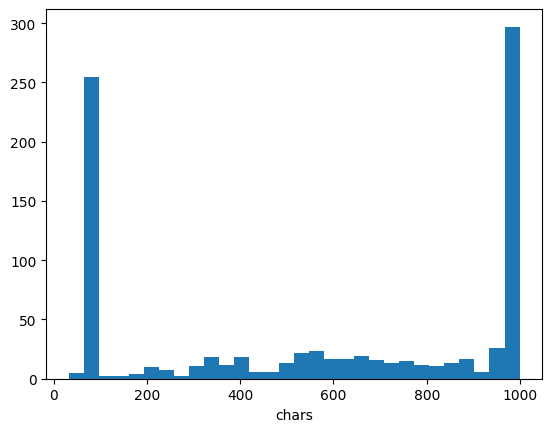

In [10]:
# page_lengths = [len(doc.page_content) for doc in docs]
# print(page_lengths)

import matplotlib.pyplot as plt

lengths = [len(doc.page_content) for doc in docs]
print(f"Chunks: {len(docs)}")
print(f"Avg: {sum(lengths)/len(lengths):.0f} chars | Min: {min(lengths)} | Max: {max(lengths)}")
plt.hist(lengths, bins=30); plt.xlabel("chars"); plt.show()

In [14]:
import psycopg2

def collection_has_data(connection_str, collection_name):
    try:

        conn = psycopg2.connect(connection_str)
        cur = conn.cursor()
        cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
        cur.execute("""
            SELECT COUNT(*) FROM langchain_pg_embedding e
            JOIN langchain_pg_collection c ON e.collection_id = c.uuid
            WHERE c.name = %s
        """, (collection_name,))
        count = cur.fetchone()[0]
        conn.close()
        return count > 0
    except:
        return False

connection_str = os.getenv('CONNECTION_KEY')
collection_name = 'ML knowledge'

In [15]:
conn = psycopg2.connect(CONNECTION_STRING)
cur = conn.cursor()
cur.execute("SELECT * FROM pg_available_extensions WHERE name = 'vector';")
result = cur.fetchone()
print(f"Extension details: {result}")
conn.close()

Extension details: ('vector', '0.8.2', '0.8.2', 'vector data type and ivfflat and hnsw access methods')


In [16]:
if collection_has_data(connection_str, collection_name):
    print(f'collection already exist -connecting to existing data')
    db = PGVector(
    embeddings=embeddings,
    # documents=docs,
    collection_name= collection_name,
    connection =connection_str,
)
    
else:
    print(f'collection empty, embedding and inserting documents')
    db = PGVector.from_documents(
    embedding=embeddings,
    documents=docs,
    collection_name= collection_name,
    connection =CONNECTION_STRING,
)
    print(f"Successfully stored {len(docs)} chunks in PostgreSQL.")


collection empty, embedding and inserting documents
Successfully stored 895 chunks in PostgreSQL.


In [ ]:
# db = PGVector.from_documents(
#     embedding=embeddings,
#     documents=docs,
#     collection_name='document1',
#     connection =CONNECTION_STRING,
# )

# print(f"Successfully stored {len(docs)} chunks in PostgreSQL.")

In [17]:
retriever = db.as_retriever()

In [ ]:
@tool(description = 'content_and artifact')
def retrieve_context(query: str):
    retrieved_doc = db.similarity_search(query, k = 3)
    serialized = "\n\n".join(f"Source: {doc.metadata} \n Content: {doc.page_content}" for doc in retrieved_doc)

    return serialized, retrieved_doc


In [18]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
# from langchain.evaluation.qa import QAGenerateChain, QAEvalChain

# template = """You are a helpful assistant. You will be provided with a document and a question.
# Your task is to answer the question based on the content of the document. 
# here are the relevant section: {context}
# Question: {question}
# These are the past messages between you and the user, please use this history list to answer the
# question as well.
# History: {history}
# """


prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful ML assistant. Context: {context}"),
    MessagesPlaceholder(variable_name="history"),
    ("human", "{question}"),
])

# use_tools = [retrieve_context]
# agent = create_agent(model, use_tools, system_prompt= prompt) #set up template and the tools





In [19]:
# implement thread-level memory (short term memory)
store = {}
def get_section_history(session_id) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]


In [28]:
history = []
chain = prompt | model 
chain_with_history = RunnableWithMessageHistory(
    chain,
    get_section_history,
    input_messages_key = 'question',
    history_messages_key = 'history'
)

section_id = str(uuid7())
# print(section_id)
while True:
    print("--------------------------------------------")
    question = input("Enter your question (or 'exit' to quit): ")
    print(f'Human question:{question}')
    
    # print(question)
    if question.lower() == 'exit':
        break

    embedded_question = embeddings.embed_query(question)
    context = db.similarity_search_by_vector(embedded_question)
    


    # result = chain.invoke({"context": context, "question": question, "history": history})
    
    
    with get_openai_callback()as cb:
        result = chain_with_history.invoke(
        {"question": question, "context": context}, 
        config={"configurable": {"session_id": section_id}}
    )
        print(f"Input tokens:  {cb.prompt_tokens}")
        print(f"Output tokens: {cb.completion_tokens}")
        print(f"Total tokens:  {cb.total_tokens}")
        print(f"Cost:          ${cb.total_cost:.5f}")

        print(f'AI response: {result.content}')
  
        print('------')
    # result.content.pretty_print()
    # print('------')
    history.append(f"Human question: {question}\ AI response: {result.content}")
    print(f'history: {history}')
    # print(result.content)

--------------------------------------------


<>:44: SyntaxWarning: invalid escape sequence '\ '
<>:44: SyntaxWarning: invalid escape sequence '\ '
C:\Users\panlw\AppData\Local\Temp\ipykernel_9880\3686056844.py:44: SyntaxWarning: invalid escape sequence '\ '
  history.append(f"Human question: {question}\ AI response: {result.content}")


Human question:whats ai
Input tokens:  870
Output tokens: 76
Total tokens:  946
Cost:          $0.00055
AI response: AI stands for artificial intelligence, which refers to the simulation of human intelligence processes by machines, especially computer systems. These processes include learning (the acquisition of information and rules for using the information), reasoning (using rules to reach approximate or definite conclusions), and self-correction. AI is used in various applications such as speech recognition, natural language processing, image recognition, and decision-making.
------
history: ['Human question: whats ai\\ AI response: AI stands for artificial intelligence, which refers to the simulation of human intelligence processes by machines, especially computer systems. These processes include learning (the acquisition of information and rules for using the information), reasoning (using rules to reach approximate or definite conclusions), and self-correction. AI is used in var